# 03 - Feature Engineering
Goal: create new features, split, scale, and save train_fe.csv / test_fe.csv.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

In [2]:
# Load the raw data
df = pd.read_csv("../data/raw/Telco_Customer_Churn.csv")

# Fix TotalCharges: text -> number, blanks (new customers) -> 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# Drop the ID column
df = df.drop(columns=["customerID"])

# Target: Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Merge "No internet service" / "No phone service" into "No"
service_cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for col in service_cols:
    df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

# Binary encoding (Yes/No -> 1/0)
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"] + service_cols
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

# NOTE: InternetService, Contract, PaymentMethod are still TEXT here.
# We one-hot encode them AFTER creating features (we need PaymentMethod's text).
print("Shape:", df.shape)

Shape: (7043, 20)


In [6]:
# Only 3 columns should be "object" (text) at this point
print(df.dtypes[df.dtypes == "object"])

Series([], dtype: object)


In [4]:
# 1. num_addons: how many of the 6 add-on services the customer has (0 to 6)
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
df["num_addons"] = df[addon_cols].sum(axis=1)

# 2. has_family: 1 if the customer has a partner OR dependents
df["has_family"] = ((df["Partner"] == 1) | (df["Dependents"] == 1)).astype(int)

# 3. is_autopay: 1 if the payment method contains the word "automatic"
df["is_autopay"] = df["PaymentMethod"].str.contains("automatic").astype(int)

# 4. avg_charge: average amount paid per month so far
#    tenure = 0 would divide by zero, so for those new customers we use MonthlyCharges
tenure_safe = df["tenure"].replace(0, 1)
df["avg_charge"] = np.where(df["tenure"] == 0,
                            df["MonthlyCharges"],
                            df["TotalCharges"] / tenure_safe)

# 5. charge_diff: current monthly bill minus the average bill so far
#    positive = the bill has gone up since the customer joined
df["charge_diff"] = df["MonthlyCharges"] - df["avg_charge"]

# 6. tenure_group: bins, same as in the EDA notebook
df["tenure_group"] = pd.cut(df["tenure"],
                            bins=[-1, 12, 24, 48, 72],
                            labels=["0-12", "13-24", "25-48", "49-72"])

# Look at the new columns
df[["num_addons", "has_family", "is_autopay", "avg_charge", "charge_diff", "tenure_group"]].head()

,num_addons,has_family,is_autopay,avg_charge,charge_diff,tenure_group
0,1,1,0,29.850000,0.000000,0-12
1,2,0,0,55.573529,1.376471,25-48
2,2,0,0,54.075000,-0.225000,0-12
3,3,0,1,40.905556,1.394444,25-48
4,0,0,0,75.825000,-5.125000,0-12


In [5]:
# Now encode the 3 text columns, plus our new tenure_group
multi_cols = ["InternetService", "Contract", "PaymentMethod", "tenure_group"]
df = pd.get_dummies(df, columns=multi_cols, drop_first=True, dtype=int)

print("Shape now:", df.shape)
print("Text columns left:", (df.dtypes == "object").sum())

Shape now: (7043, 32)
Text columns left: 0


In [7]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Same settings as Phase 4 (random_state=42), so the same customers
# land in train and test. This makes the comparison in Phase 6 fair.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (5634, 31)  Test: (1409, 31)


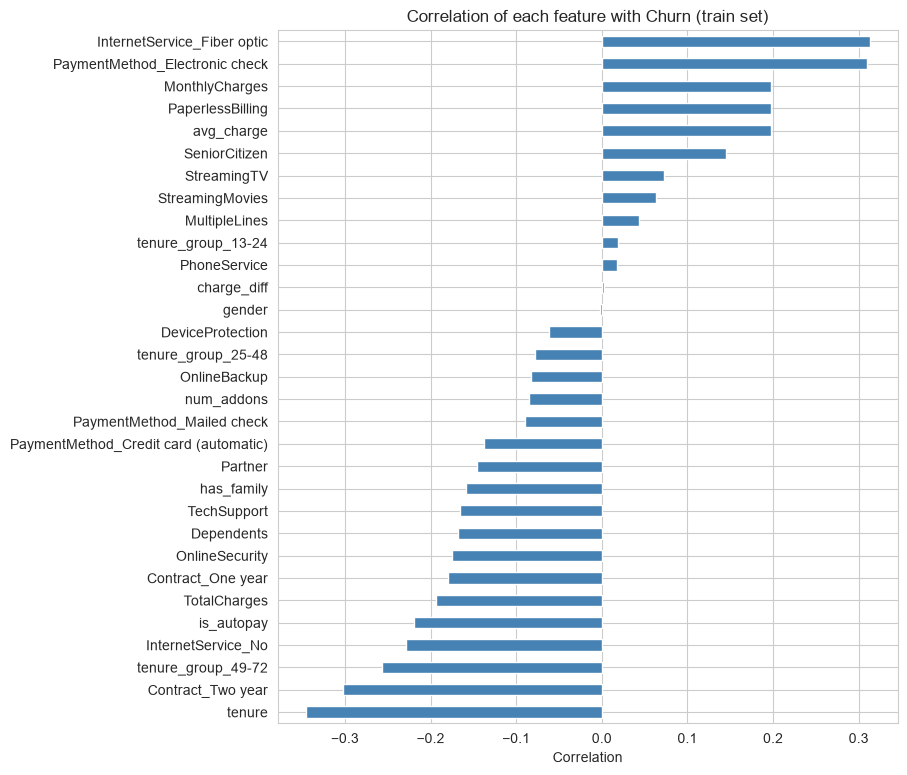

In [9]:
# We look ONLY at the training data. Studying the test set would be peeking.
train_view = X_train.copy()
train_view["Churn"] = y_train

# Correlation of every feature with Churn (-1 to +1)
# Positive = more of this feature, more churn. Negative = less churn.
corr = train_view.corr()["Churn"].drop("Churn").sort_values()

# Bar chart
plt.figure(figsize=(8, 9))
corr.plot(kind="barh", color="steelblue")
plt.title("Correlation of each feature with Churn (train set)")
plt.xlabel("Correlation")
plt.savefig("../reports/figure/feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

num_addons
0    20.9
1    45.8
2    36.2
3    27.8
4    23.0
5    12.5
6     4.7
Name: Churn, dtype: float64


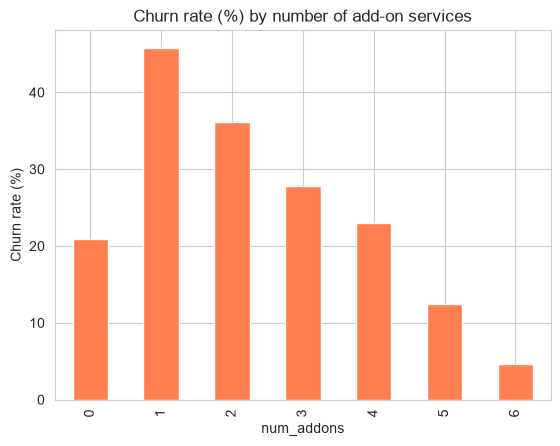

In [10]:
# Mean of Churn (0/1) = churn rate
rate = train_view.groupby("num_addons")["Churn"].mean() * 100
print(rate.round(1))

rate.plot(kind="bar", color="coral")
plt.title("Churn rate (%) by number of add-on services")
plt.ylabel("Churn rate (%)")
plt.savefig("../reports/figure/churn_by_addons.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Columns with large or varied values. The 0/1 columns stay as they are.
num_cols = ["tenure", "MonthlyCharges", "TotalCharges",
            "num_addons", "avg_charge", "charge_diff"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])  # learn from train
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])        # only apply to test

print(X_train_scaled[num_cols].describe().round(2))

        tenure  MonthlyCharges  TotalCharges  num_addons  avg_charge  \
count  5634.00         5634.00       5634.00     5634.00     5634.00   
mean     -0.00           -0.00          0.00        0.00       -0.00   
std       1.00            1.00          1.00        1.00        1.00   
min      -1.32           -1.54         -1.01       -1.11       -1.69   
25%      -0.96           -0.97         -0.83       -1.11       -0.96   
50%      -0.14            0.18         -0.40       -0.03        0.19   
75%       0.92            0.83          0.67        0.51        0.84   
max       1.61            1.79          2.80        2.13        1.87   

       charge_diff  
count      5634.00  
mean         -0.00  
std           1.00  
min          -7.27  
25%          -0.45  
50%           0.00  
75%           0.44  
max           7.36  


In [12]:
train_fe = X_train_scaled.copy()
train_fe["Churn"] = y_train

test_fe = X_test_scaled.copy()
test_fe["Churn"] = y_test

# New file names (_fe = feature engineered). Phase 4 files stay unchanged.
train_fe.to_csv("../data/processed/train_fe.csv", index=False)
test_fe.to_csv("../data/processed/test_fe.csv", index=False)
joblib.dump(scaler, "../models/scaler_fe.pkl")

print("Saved train_fe.csv, test_fe.csv and scaler_fe.pkl")

Saved train_fe.csv, test_fe.csv and scaler_fe.pkl


## My Notes

1. I created 6 new features: num_addons, has_family, is_autopay, avg_charge, charge_diff, and tenure_group.
2. The strongest feature by correlation was tenure (or Contract_Two year negatively, and InternetService_Fiber optic positively).
3. My new feature that looked most useful was num_addons because it directly captures customer engagement across all security and support services in a single score.
4. These features are safe from leakage because they are calculated using only each customer's own row without relying on dataset-wide statistics.